# Cycle 1 — Model Explainability (SHAP)

This notebook answers one question: **why does the model make the predictions it does?**

Accuracy tells us the model is right **52.85%** of the time on the chronological test set (the held-out final 20% by date). SHAP tells us *which features* caused each prediction and by how much. This is essential for:
1. Validating that the model uses sensible football logic
2. Identifying which features are most important for each outcome
3. Writing the discussion section of the report

### What is SHAP?

**SHAP** (SHapley Additive exPlanations) is based on game theory. It calculates, for each feature in each prediction, how much that feature **pushed the prediction** towards or away from a class.

- A **positive SHAP value** for a feature means it pushed the model towards predicting that class
- A **negative SHAP value** means it pushed the model away from that class
- SHAP values sum exactly to the model's output — they are mathematically consistent

In [3]:
import sys, os             
import pandas as pd        
import numpy as np         
import joblib              
import shap                
import matplotlib.pyplot as plt  
import warnings
warnings.filterwarnings('ignore')  

from sklearn.metrics import accuracy_score 


_here = os.getcwd()                                      
while not os.path.isdir(os.path.join(_here, 'data')):    
    _p = os.path.dirname(_here)                          
    if _p == _here: raise RuntimeError('project root not found') 
    _here = _p
if _here not in sys.path:
    sys.path.insert(0, _here)                     

from config import Paths, ensure_dirs  
ensure_dirs() 


## Imports and Load Saved Model

In [ ]:

model        = joblib.load(str(Paths.C1_MODEL))     # best tuned XGBoost model (chronological split)
feature_cols = joblib.load(str(Paths.C1_FEATURES))  # list of 33 feature column names in training order


df = pd.read_csv(str(Paths.PL_MATCHES_PROCESSED)).sort_values('Season').reset_index(drop=True)

split_idx = int(len(df) * 0.8)             # 80% train / 20% test boundary (same as tuning notebook)
X_test = df.iloc[split_idx:].drop(columns=['FTR', 'Season'])[feature_cols]  # test features only
y_test = df.iloc[split_idx:]['FTR']        # test labels

acc = accuracy_score(y_test, model.predict(X_test))  # sanity check: confirm model still scores 52.85%
print(f'Loaded model test accuracy: {acc*100:.2f}%')
print(f'Test rows: {len(X_test)}, Features: {len(feature_cols)}')


Loaded model test accuracy: 52.85%
Test rows: 1368, Features: 33


## Compute SHAP Values

Runs the SHAP TreeExplainer on the test set to compute SHAP values for every prediction.

In [5]:
explainer = shap.TreeExplainer(model)          # TreeExplainer: fast exact SHAP for tree-based models
shap_values = explainer.shap_values(X_test)    # compute SHAP for all test samples
# shap_values shape: (n_samples, n_features, n_classes)
# each value = how much that feature pushed the model output up or down for that prediction

class_labels = ['Away Win (0)', 'Draw (1)', 'Home Win (2)']  # labels for plotting

print(f'SHAP values shape: {np.array(shap_values).shape}')
print(f'n_samples={np.array(shap_values).shape[0]}, n_features={np.array(shap_values).shape[1]}, n_classes={np.array(shap_values).shape[2]}')


SHAP values shape: (1368, 33, 3)
n_samples=1368, n_features=33, n_classes=3


## Global Feature Importance (Mean Absolute SHAP)

Calculates the mean absolute SHAP value for each feature across all predictions and all classes. This gives a single **global importance score** per feature — which feature, on average, has the most influence on any prediction.

Global Feature Importance (Mean Absolute SHAP)
      Feature  Mean |SHAP|
      DiffPts     0.125795
          AM1     0.107746
          HM1     0.075031
         HTGD     0.054212
          ATP     0.052320
         ATGD     0.047022
     HomeTeam     0.038364
     AwayTeam     0.035346
          HTP     0.032545
         HTGS     0.026871
         ATGC     0.023730
         ATGS     0.017717
         HTGC     0.017273
           MW     0.011572
  DiffFormPts     0.010548
          AM2     0.008570
    HTFormPts     0.008054
    ATFormPts     0.008020
          HM4     0.004645
          HM2     0.004003
          AM3     0.003769
          HM3     0.003118
          AM5     0.002247
          HM5     0.002061
          AM4     0.001875
HTLossStreak3     0.001578
 ATWinStreak3     0.001412
ATLossStreak3     0.000674
HTLossStreak5     0.000385
 HTWinStreak3     0.000234
 HTWinStreak5     0.000098
 ATWinStreak5     0.000019
ATLossStreak5     0.000000


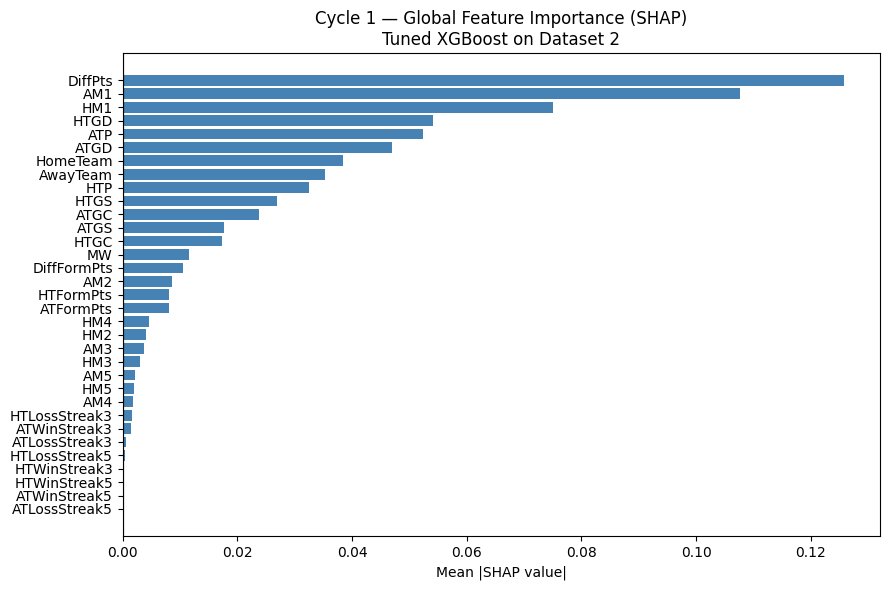

Saved → ../docs/cycle1_shap_global_importance.png


In [11]:
# Mean absolute SHAP across all classes — measures overall feature importance
shap_arr = np.array(shap_values)             # convert list-of-arrays to 3D numpy array: (n_test, 33, 3)
mean_abs_shap = np.abs(shap_arr).mean(axis=(0, 2))  # average over samples (axis 0) and classes (axis 2) → (33,)

importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Mean |SHAP|': mean_abs_shap
}).sort_values('Mean |SHAP|', ascending=False)  # rank features by importance

print('Global Feature Importance (Mean Absolute SHAP)')
print(importance_df.to_string(index=False))      # print full ranked table

# Horizontal bar chart — easier to read feature names than vertical bars
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(importance_df['Feature'][::-1], importance_df['Mean |SHAP|'][::-1], color='steelblue')
# [::-1] reverses so most important is at the top
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Cycle 1 — Global Feature Importance (SHAP)\nTuned XGBoost on Dataset 2')
ax.axvline(0, color='black', linewidth=0.8)      # zero reference line
plt.tight_layout()
plt.savefig('../../docs/cycle1_shap_global_importance.png', dpi=150)  # save for report
plt.show()
print('Saved → ../docs/cycle1_shap_global_importance.png')


- DiffPts is the most important feature — confirms that difference in team quality is the strongest predictor
- Recent form (AM1, HM1) is highly influential — recent matches carry strong predictive signal
- Goal difference (HTGD, ATGD) and points (HTP, ATP) are key contributors
- Team identity features (HomeTeam, AwayTeam) have moderate importance
- Win/loss streak features contribute very little — near-zero SHAP values

## SHAP Summary Plot (Beeswarm)

Plots a beeswarm summary — each dot is one prediction, coloured by feature value (red = high, blue = low). The x-axis shows SHAP value (impact on model output).

- A red dot (high feature value) on the right means: high values of this feature push predictions towards this class
- A blue dot (low feature value) on the right means: low values push predictions towards this class

It shows not just *which* features matter, but *how* they matter — the direction and magnitude for individual predictions.

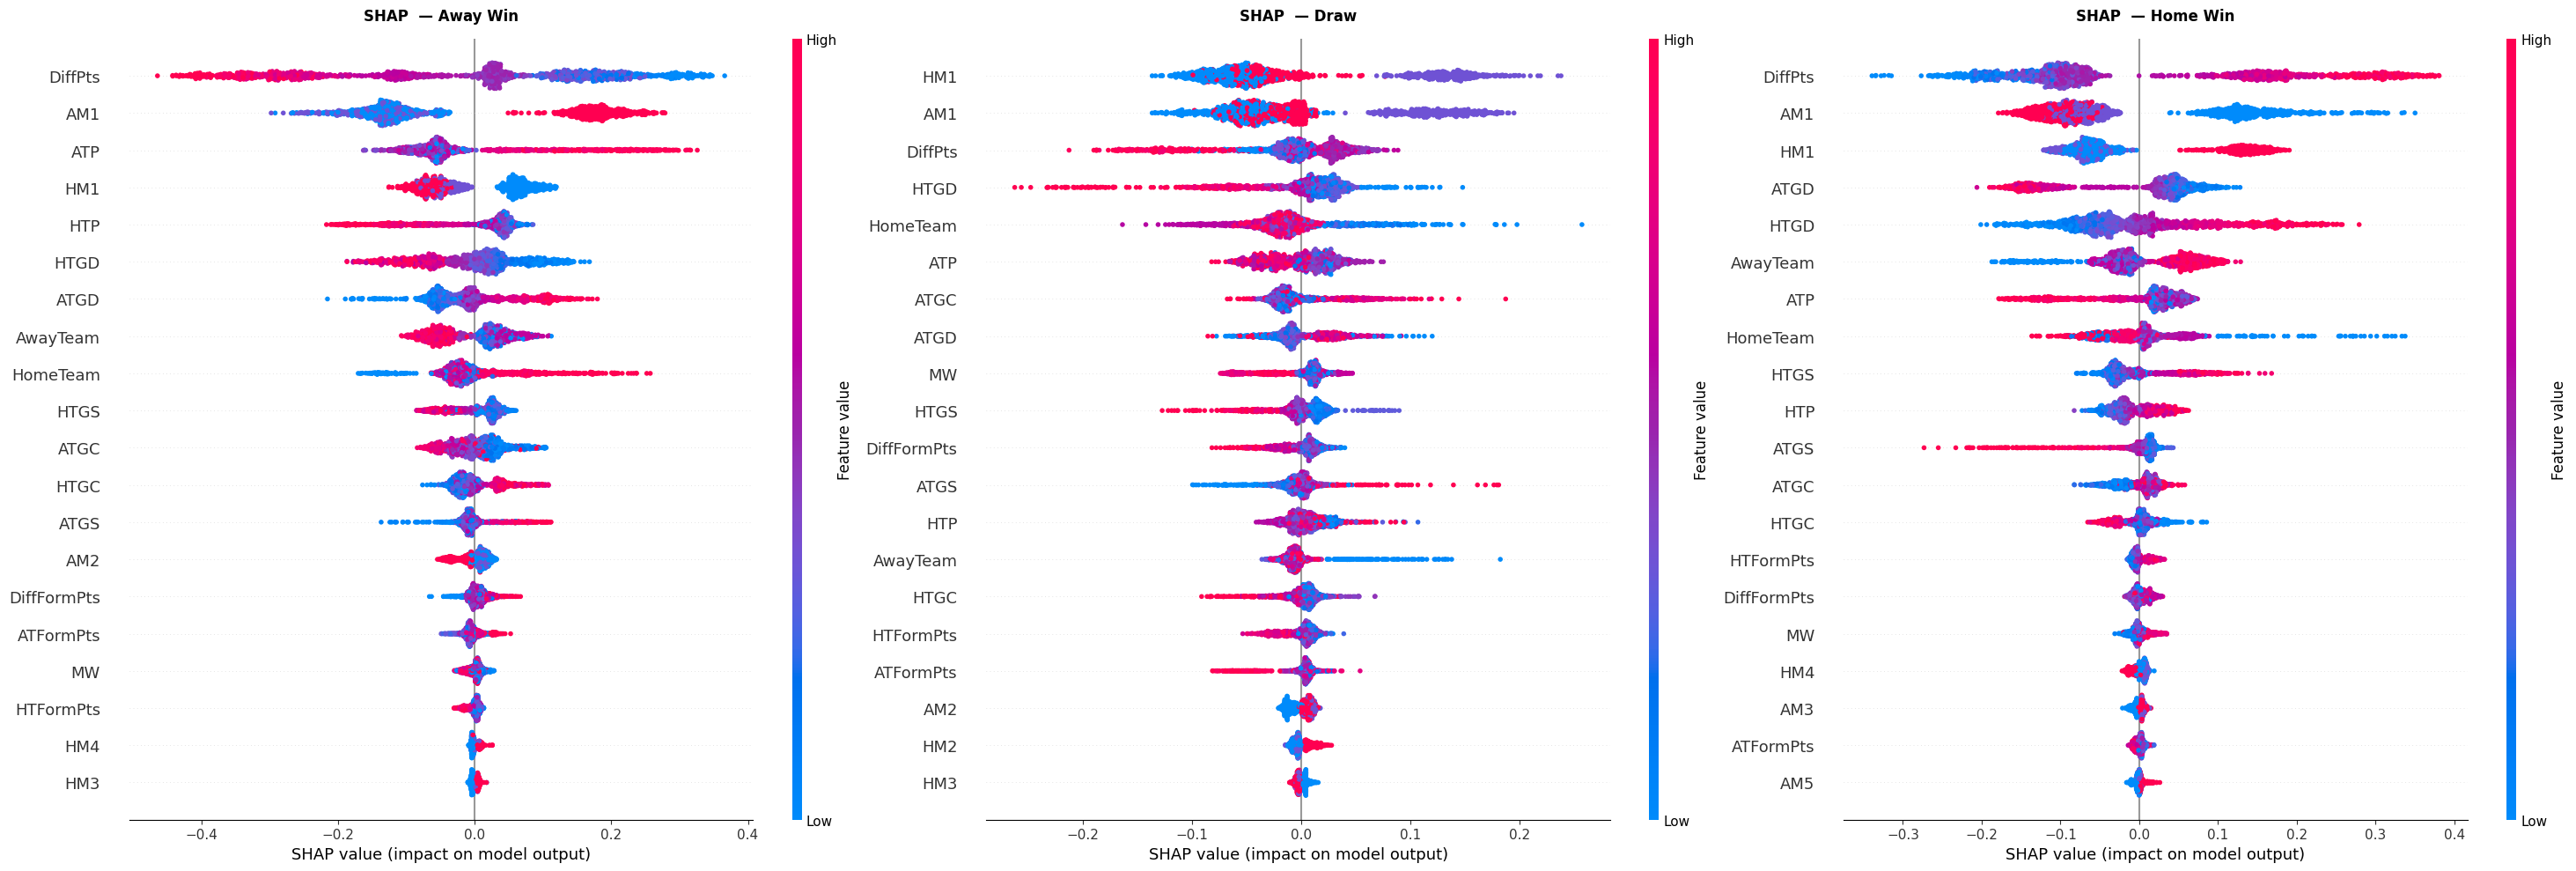

Saved 3-panel side-by-side plot → ../../docs/cycle1_shap_summary_side_by_side.png


In [13]:
import os
os.makedirs('../../docs', exist_ok=True)  # create docs folder if it doesn't exist

class_names = ['Away Win', 'Draw', 'Home Win']  # class labels for plot titles

# Create ONE wide figure with 3 columns (side-by-side)
# figsize=(18, 5) means 18 inches wide, 5 inches tall
fig, axes = plt.subplots(1, 3, figsize=(30, 10))

# Loop through all 3 classes and plot them onto the 3 axes
for i, class_name in enumerate(class_names):
    plt.sca(axes[i])  # Tell SHAP to draw on the specific column (left, middle, or right)
    
    shap.summary_plot(
        shap_arr[:, :, i],           # SHAP values for this class
        X_test,                      # feature values for colour coding
        feature_names=feature_cols,  # feature names for y-axis labels
        show=False,                  # don't display inline yet
        plot_type='dot',             # beeswarm: each dot = one sample
        plot_size=None               # CRITICAL: prevents SHAP from overriding our custom figure size
    )
    plt.title(f'SHAP  — {class_name}', pad=15, fontweight='bold')

plt.tight_layout() # Ensures labels don't overlap

# Save the combined plot for your report
fname = '../../docs/cycle1_shap_summary_side_by_side.png'
plt.savefig(fname, dpi=300, bbox_inches='tight')      
plt.show()

print(f'Saved 3-panel side-by-side plot → {fname}')



Home and Away Win predictions are largely driven by **team strength differences (DiffPts)**, with form and goal difference reinforcing the outcome—stronger teams consistently increase their respective win probabilities. Home Wins are predicted more reliably (high recall), while Away Wins follow a similar but less consistent pattern (moderate recall). In contrast, Draws have **no strong influencing feature**, with overlapping patterns across key variables, leading to very low recall and making them difficult for the model to predict accurately.


## Per-Class Feature Importance

Calculates mean absolute SHAP separately for each class (Away Win, Draw, Home Win). Shows which features drive each specific outcome.

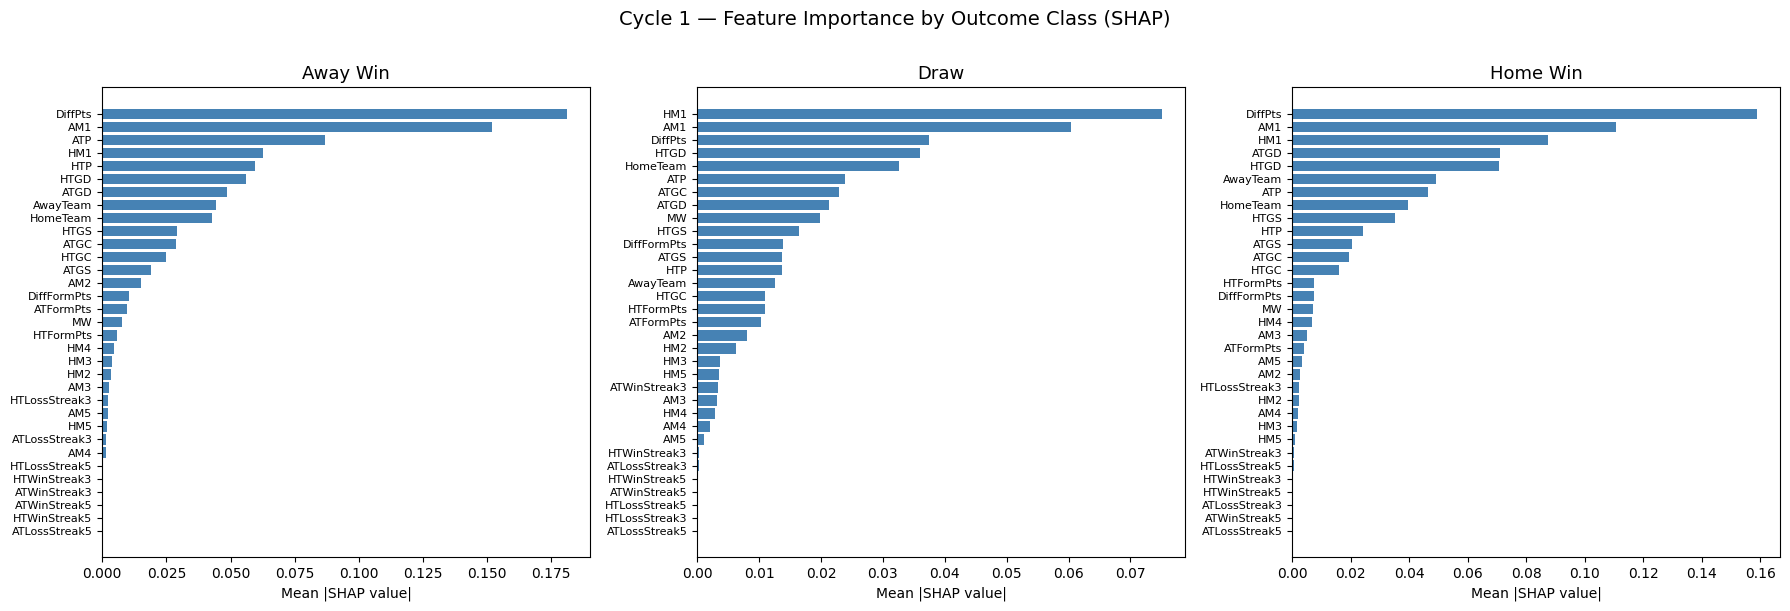

Saved → ../docs/cycle1_shap_per_class.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # one subplot per outcome class

for i, (class_name, ax) in enumerate(zip(class_names, axes)):
    mean_shap_class = np.abs(shap_arr[:, :, i]).mean(axis=0)  # mean |SHAP| for this class: (n_features,)
    sorted_idx = np.argsort(mean_shap_class)                   # sort features ascending (lowest first)

    ax.barh(
        [feature_cols[j] for j in sorted_idx],   # feature names sorted by importance
        mean_shap_class[sorted_idx],              # corresponding mean |SHAP| values
        color='steelblue'
    )
    ax.set_title(f'{class_name}', fontsize=13)
    ax.set_xlabel('Mean |SHAP value|')
    ax.tick_params(axis='y', labelsize=8)          # smaller font to fit 33 feature names

plt.suptitle('Cycle 1 — Feature Importance by Outcome Class (SHAP)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../../docs/cycle1_shap_per_class.png', dpi=150, bbox_inches='tight')  # save for report
plt.show()
print('Saved → ../docs/cycle1_shap_per_class.png')


Home and Away Win predictions are primarily driven by **team strength differences (DiffPts)**, supported by recent form and goal difference, with stronger teams consistently increasing their respective win probabilities. Home Wins are predicted more reliably due to clearer patterns in home advantage and form, while Away Wins follow a similar but slightly less consistent pattern. In contrast, Draws show **no strong driving feature**, with all key variables having weak and overlapping effects, making them inherently difficult for the model to distinguish and resulting in very low predictive performance.


## Single Prediction Explanation (Waterfall Plot)

Explains one specific prediction in detail — shows how each feature contributed to the final prediction for a single match.

Sample index: 0
Actual class:    2 (Home Win)
Predicted class: 2 (Home Win)



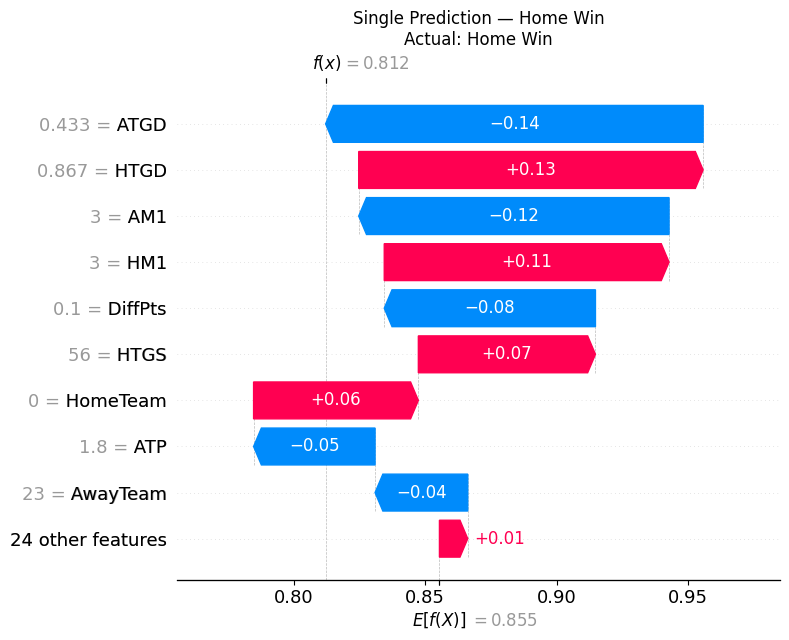

Saved → ../docs/cycle1_shap_waterfall.png


In [9]:
# Explain one specific Home Win prediction — shows which features drove this individual decision
home_win_idx = y_test[y_test == 2].index           # get indices of all actual Home Win matches
sample_idx = X_test.index.get_loc(home_win_idx[0]) # convert first Home Win index to positional index

predicted_class = model.predict(X_test.iloc[sample_idx:sample_idx+1])[0]  # model's predicted class
actual_class    = y_test.iloc[sample_idx]            # actual result

print(f'Sample index: {sample_idx}')
print(f'Actual class:    {actual_class} ({class_names[actual_class]})')
print(f'Predicted class: {predicted_class} ({class_names[predicted_class]})')
print()

# Build SHAP Explanation object for the waterfall plot
shap_vals_sample = shap_arr[sample_idx, :, predicted_class]  # SHAP values for the predicted class only
base_val = explainer.expected_value[predicted_class]          # model's average output (baseline)

shap_explanation = shap.Explanation(
    values=shap_vals_sample,         # per-feature SHAP contributions for this sample
    base_values=base_val,            # starting point (average model output across training data)
    data=X_test.values[sample_idx],  # actual feature values for this match
    feature_names=feature_cols       # feature name labels
)

plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_explanation, show=False)  # waterfall: shows cumulative feature contributions
plt.title(f'Single Prediction — {class_names[predicted_class]}\nActual: {class_names[actual_class]}')
plt.tight_layout()
plt.savefig('../../docs/cycle1_shap_waterfall.png', dpi=150, bbox_inches='tight')  # save for report
plt.show()
print('Saved → ../docs/cycle1_shap_waterfall.png')



- The waterfall traces exactly how this prediction was made — starting from the base rate and adding each feature's contribution
- Features with the longest bars had the most influence on this specific prediction
- This type of explanation is what will be shown in the Streamlit dashboard for individual match predictions

Waterfall plots support explainable AI (XAI) requirements. For a deployed prediction tool, explaining individual predictions builds user trust and satisfies transparency criteria.